# <center>Laboratorium 12<br>Metody Numeryczne</center>    


In [1]:
import numpy as np
import main
import matplotlib
import matplotlib.pyplot as plt
import math
import scipy as sp

Instrukcja:  
Na zajęciach należy wykonać poniższe zadania, a następnie sporządzić sprawozdanie zawierające odpowiedzi z komentarzami.

**Cel zajęć:** Celem zajęć jest zapoznanie się z numerycznymi metodami rozwiązywania równań różniczkowych
zwyczajnych. Będziemy rozpatrywać równania różniczkowe postaci
$$\dot{x}(t) = f(x(t), t)$$
gdzie:

$x(t) \in \mathbb{R}^n$,

$t \ge 0$ 


z warunkiem początkowym $x(0) = x0$

Jest to tak zwany problem początkowy (problem Cauchy’ego) dla równań różniczkowych zwyczajnych.

**Zadanie 1.**  
Zaimplementuj metodę *solve_euler* z main.py 


***Zadanie 2.*** 

Rozwiąż równanie 
$
\dot{x}(t)=\frac{x+t}{x-t}
$, 

$x(0)=1$ (równanie to posiada rozwiązanie dokładne: 
$x(t)=t+\sqrt{1+2t^2}$). 

Narysuj wykres podanego rozwiązania dokładnego oraz uzyskanych rozwiązań numerycznych.


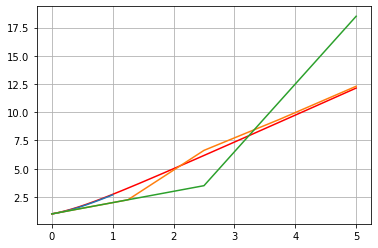

In [2]:
f_real = lambda t: t + np.sqrt(1 + 2 * t**2)
t=np.linspace(0,5,1000)
plt.plot(t,f_real(t),'r')




def f(x,t):
    return (x+t)/(x-t)
t=np.linspace(0,1,10)
s=main.solve_euler(f,t,(1.,))
plt.plot(t,s)
t=np.linspace(0,5,5)
s=main.solve_euler(f,t,(1.,))
plt.plot(t,s)
t=np.linspace(0,5,3)
s=main.solve_euler(f,t,(1.,))
plt.plot(t,s)
plt.grid()


Już dla h=0.5 różnica od oryginału jest mało widoczna na wykresie

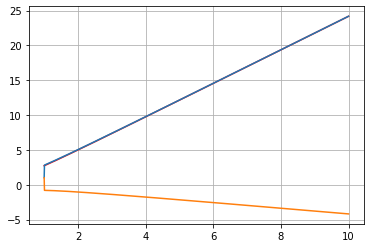

In [3]:
t=np.linspace(1,10,1000)
plt.plot(t,f_real(t),'r')
t=np.linspace(1,10,1000)
s=main.solve_euler(f,t,(1.01,))
plt.plot(t,s)
s=main.solve_euler(f,t,(0.99,))
plt.plot(t,s)
plt.grid()

Na funkcji tej można pokazać wady Metody Eulera jeśli zamiast x=0 podstawimy x=1 (wektor t zacznie się od 1 a nie od 0). 
1) w miejscu zerowym mianownika nie jest możliwe wykonanie kroku, trzeba przez to miejsce przejść

2)już od przybliżenia do 0.01 do x początkowego pojawia się wyraźny błąd związany z zbyt dużą bliskością nieciągłości f(x,t)

3)nadal im mniejszy krok tym lepiej, tym mniej nadepnięcie na nieciągłość będzie bolesne, choć zwiększa prawdopodobieństwo wpadnięcia w niebezpieczny przedział kolejnej nieciągłości jeśli taka jest

4) dla podanej f(x,t) zależnie od STRONY od której zakładamy t bliższe warunkowi początkowemu możemy otrzymać zupełnie inny wynik !

Zatem używając metody Eulera trzeba mieć pewność że w żadnym kroku nie trafimy zbyt blisko nieciągłości, wystarczy że trafimy w niego tylko raz i reszta przybliżenia od tamtego momentu będzie obarczona ogromnym (choć dla wszystkich punktów od tmatego miejsca identycznym) błędem
Choć jak już przebrniemy przez 1), 2) i 3) to przybliżenie (patrz : niebieski wykres) jest całkiem dobre (pomijając błąd nieprawidłowego warunku początkowego).

***Zadanie 3.*** 

Rozwiąż układ równań różniczkowych: 
$$
\begin{array}{l}
\dot{x_1}(t)={x_3}(t)\\
\dot{x_2}(t)={x_4}(t)\\
\dot{x_3}(t)=-\frac{x_1(t)}{{(x_1(t)^2+x_2(t)^2)}^{\frac{3}{2}}}\\
\dot{x_4}(t)=-\frac{x_2(t)}{{(x_1(t)^2+x_2(t)^2)}^{\frac{3}{2}}}
\end{array}
$$
      
z warunkiem początkowym $x(0)=[1,0,0,1]^T$.
    
Dla takiego warunku początkowego układ ten ma rozwiązanie szczególne 
$$
x(t)=\left[\begin{matrix}
cos(t)\\
sin(t)\\
-sin(t)\\
cos(t)
\end{matrix}\right].
$$  

Narysuj wykres podanego rozwiązania szczegółowego oraz uzyskanych rozwiązań numerycznych.

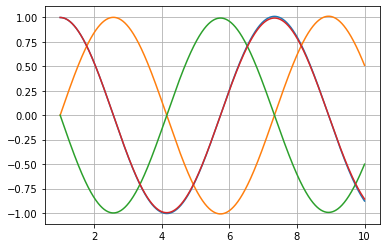

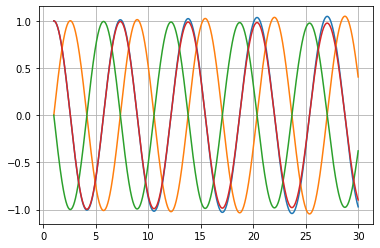

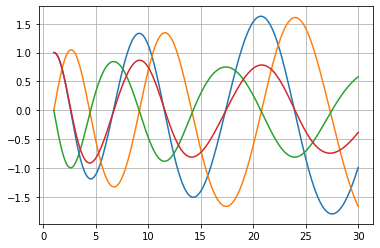

In [4]:
def func(y :np.array,t :np.array):
 yn=[0.0,0.0,0.0,0.0]
 yn[0]=y[2]
 yn[1]=y[3]
 yn[2]=-y[0]/(y[0]**2+y[1]**2)**1.5
 yn[3]=-y[1]/(y[0]**2+y[1]**2)**1.5
 return yn

t=np.linspace(1,10,10000)
s=main.solve_euler(func,t,[1,0,0,1])
s=np.transpose(s)
plt.plot(t,s[0])
plt.plot(t,s[1])
plt.plot(t,s[2])
plt.plot(t,s[3])
plt.grid()

t=np.linspace(1,30,30000)
s=main.solve_euler(func,t,[1,0,0,1])
s=np.transpose(s)
plt.figure()
plt.plot(t,s[0])
plt.plot(t,s[1])
plt.plot(t,s[2])
plt.plot(t,s[3])
plt.grid()

t=np.linspace(1,30,1000)
s=main.solve_euler(func,t,[1,0,0,1])
s=np.transpose(s)
plt.figure()
plt.plot(t,s[0])
plt.plot(t,s[1])
plt.plot(t,s[2])
plt.plot(t,s[3])
plt.grid()

Euler zwiększa okres funkcji oraz ich maksima oraz minima, co jest najpewniej związane z ciągle zwiększającą się wartością t od której zależy wartość f(x,t) a także przechodzeniem błędów z poprzedniego kroku na następny.
Im mniejsze h tym efekt powoduje mniejsze błędy.

***Zadanie 4.*** 

Rozwiąż układ równań $\dot{x}(t)=\mathbf{A}x(t)$, gdzie macierz 
$
\mathbf{A}$ dana jest wzorem:  
$$
\mathbf{A}=\left[\begin{matrix}
-667 & 333 \\
 666 & -334
\end{matrix}\right]
$$

z warynkiem początkowym $x(0)=[0, 3]^T$

Narysuj wykres uzyskanych rozwiązań numerycznych. Jakie jest rozwiązanie dokładne tego równania?

<ipython-input-5-0b5be63c9a5b>:3: RuntimeWarning: overflow encountered in matmul
  return A@y
c:\Users\domin\OneDrive\Pulpit\Metody_Numeryczne\laboratorium-12-ADstr\main.py:31: RuntimeWarning: invalid value encountered in add
  new[ind]=new[ind-1]+f


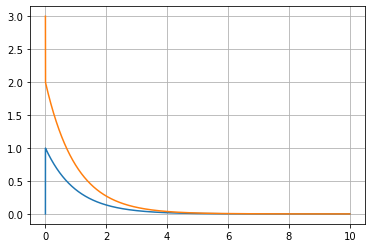

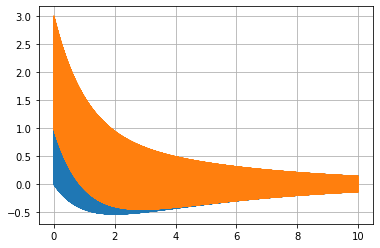

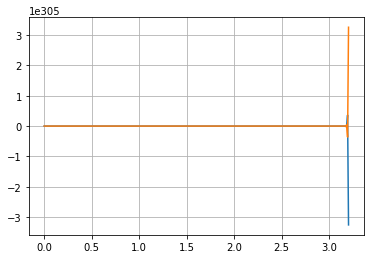

In [5]:
def fa(y,t):
    A=np.array([[-667, 333],[666, -334]])
    return A@y

t=np.linspace(0,10,10000)
x0 = np.array([0, 3])
s=main.solve_euler(fa,t,x0)
s=np.transpose(s)
plt.figure()
plt.plot(t,s[0])
plt.plot(t,s[1])
plt.grid()

t=np.linspace(0,10,5002)
s=main.solve_euler(fa,t,x0)
s=np.transpose(s)

plt.figure()
plt.plot(t,s[0])
plt.plot(t,s[1])
plt.grid()

t=np.linspace(0,10,1000)
s=main.solve_euler(fa,t,x0)
s=np.transpose(s)

plt.figure()
plt.plot(t,s[0])
plt.plot(t,s[1])
plt.grid()

In [ ]:
"""Rozwiązaniem tego równania jest e**(A*(t-t0))*x0 gdzie x(t0)=x0"""

Euler dawał przybliżenie pozwalające przyjrzeć "wyglądowi" funkcji dopiero od odpowiednio małego h

***Zadanie 4.*** 

Orbita Arenstorfa. Jest to przykład z astronomii opisujący zredukowany problem trzech ciał. Rozważa się dwa ciała o masach $\mu$ i $\mu'=1-\mu$, poruszające się w ruchu kołowym na jednej płaszczyźnie oraz ciało o pomijalnej masie poruszające się między nimi w tej samej płaszczyźnie. Dany jest układ równań różniczkowych:
$$
\begin{array}{l}
\dot{x_1}(t)={x_2}(t)\\
\dot{x_2}(t)={x_1}(t)+2x_4(t)-\mu'\frac{x_1+\mu}{D_1}-\mu\frac{x_1-\mu'}{D_2}\\
\dot{x_3}(t)=x_4(t)\\
\dot{x_4}(t)=x_3(t)-2x_2(t)-\mu'\frac{x_3(t)}{D_1}
-\mu\frac{x_3(t)}{D_2}\end{array}.
$$

gdzie
$$
\begin{array}{l}
D_1=((x_1(t)+\mu)^2+{x_3}^2(t))^\frac{3}{2}\\
D_2=((x_1(t)-\mu')^2+{x_3}^2(t))^\frac{3}{2}\\
\mu=0.012277471\end{array}.
$$

Zmienne $x_1$ i $x_3$ odpowiadają za współrzędne na płaszczyźnie trzeciego ciała zaś $x_2$ i $x_4$
są odpowiednio prędkościami. Warto zwrócić uwagę, że zarówno czas jak i masa zostały
w równaniach przeskalowane, i nie mają bezpośredniej interpretacji fizycznej, należy je
traktować jako zmienne bezwymiarowe. Dla pewnych warunków początkowych i czasu
symulacji
$$
\begin{array}{l}
x_1(0) = 0.994\\
x_2(0) = 0\\
x_3(0) = 0\\
x_4(0) = − 2.00158510637908252240537862224\\
T = 17.0652165601579625588917206249.\end{array}
$$
dokładne rozwiązanie tych równań jest okresowe ($x(0)=x(T)$).

Narysuj wykres uzyskanych rozwiązań numerycznych.

błąd po x1 :  0.0027504442153544195  błąd po x2 :  -0.09459549634484131
błąd po x1 :  0.06794343989059903  błąd po x2 :  -0.6677797520392093
błąd po x1 :  -41.823258820991256  błąd po x2 :  -29.061236764977078


KeyboardInterrupt: 

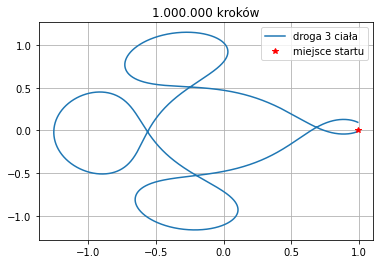

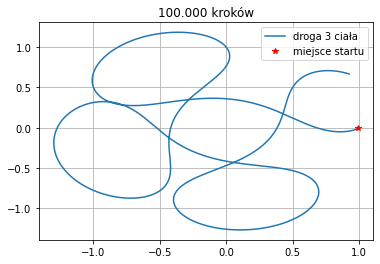

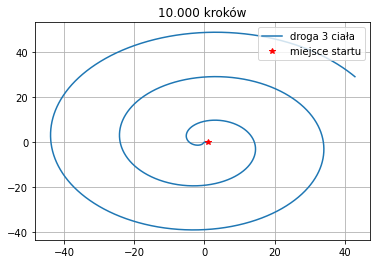

In [6]:
def orb(y :np.array,t :np.array):
 yn=[0.0,0.0,0.0,0.0]
 u=0.012277471
 up=1-u
 D1=((y[0]+u)**2+y[2]**2)**(3/2)
 D2=((y[0]-up)**2+y[2]**2)**(3/2)
 yn[0]=y[1]
 yn[1]=y[0]+2*y[3]-up*(y[0]+u)/D1-u*(y[0]-up)/D2
 yn[2]=y[3]
 yn[3]=y[2]-2*y[1]-up*y[2]/D1-u*y[2]/D2
 return yn

T = 17.0652165601579625588917206249
t=np.linspace(0,T,1000000)
x0=np.array([0.994,0,0,-2.00158510637908252240537862224])
s=main.solve_euler(orb,t,x0)
s=np.transpose(s)
plt.plot(s[0],s[2])
plt.plot(s[0][0],s[2][0],'r*')
plt.legend(["droga 3 ciała", "miejsce startu"], loc='upper right')
plt.grid()
plt.title('1.000.000 kroków')
print("błąd po x1 : ",s[0][0]-s[0][-1]," błąd po x2 : ",s[2][0]-s[2][-1])

t=np.linspace(0,T,100000)
x0=np.array([0.994,0,0,-2.00158510637908252240537862224])
s=main.solve_euler(orb,t,x0)
s=np.transpose(s)
plt.figure()
plt.plot(s[0],s[2])
plt.plot(s[0][0],s[2][0],'r*')
plt.legend(["droga 3 ciała", "miejsce startu"], loc='upper right')
plt.grid()
plt.title('100.000 kroków')
print("błąd po x1 : ",s[0][0]-s[0][-1]," błąd po x2 : ",s[2][0]-s[2][-1])

t=np.linspace(0,T,10000)
x0=np.array([0.994,0,0,-2.00158510637908252240537862224])
s=main.solve_euler(orb,t,x0)
s=np.transpose(s)
plt.figure()
plt.plot(s[0],s[2])
plt.plot(s[0][0],s[2][0],'r*')
plt.legend(["droga 3 ciała", "miejsce startu"], loc='upper right')
plt.grid()
plt.title('10.000 kroków')
print("błąd po x1 : ",s[0][0]-s[0][-1]," błąd po x2 : ",s[2][0]-s[2][-1])

t=np.linspace(0,2*T,2000000)
x0=np.array([0.994,0,0,-2.00158510637908252240537862224])
s=main.solve_euler(orb,t,x0)
s=np.transpose(s)
plt.figure()
plt.plot(s[0],s[2])
plt.plot(s[0][0],s[2][0],'r*')
plt.legend(["droga 3 ciała", "miejsce startu"], loc='upper right')
plt.grid()
plt.title('2T,2.000.000 kroków')

Widzimy tu nałożenie się zjawisk zaobserwowanych w 2 poprzednich zadaniach. Warto dodać że dłuższe t i większe h tym więcej błędu będzie dodawane do następnych kroków. Gdyż błąd z poprzedniego kroku jest dodawany do następnego.

**Bibliografia**

1. J. C. Butcher. Numerical Methods for Ordinary Differential Equations. John Wiley and Sons, Ltd., 2003.
2. Z. Fortuna, B. Macukow, and J. Wąsowski. Metody numeryczne. WNT Warszawa, 1982.
3. E. Hairer, S.P. Nørsett, and G. Wanner. Solving Ordinary Differential Equations: I Nonstiff problems. Springer, 2 edition, 2000.
4. W. Mitkowski. Równania macierzowe i ich zastosowania. Wydawnictwa AGH, Kraków,2 edition, 2007.
5. A. Ralston. Wstęp do analizy numerycznej. PWN, Warszawa, 1965.
6. L. F. Shampine, I. Gladwell, and S. Thompson. Solving ODEs with MATLAB. Cambridge University Press, 2003.
7. Stoer, J., Burlirsch, R., 1980: Wstêp do metod numerycznych, tom 2. PWN Warszawa.
